<a href="https://colab.research.google.com/github/LielUziahu/Stylophora-pistillata-FPs/blob/main/Settlment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


REPORT: Settlment_Ambient.csv

[DATA DESCRIPTION (N, Mean, 95% CI)]
morph  count      mean       std     ci_95
   HF     28 45.357143 22.481621  7.236637
   NF     21 35.238095 22.884284  8.612829
   PF     17 38.529412 35.034122 14.834813

[STATISTICAL ANALYSIS - ANOVA]
                sum_sq    df         F    PR(>F)
C(morph)   1307.056914   2.0  0.940899  0.395692
Residual  43758.473389  63.0       NaN       NaN


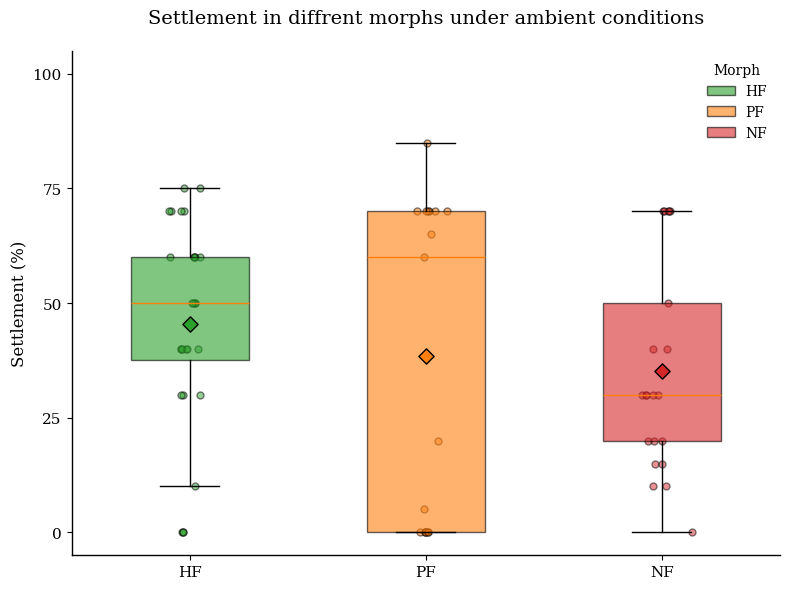


REPORT: Settlement_Depth.csv

[DATA DESCRIPTION (N, Mean, 95% CI)]
morph Light  count      mean       std     ci_95
   HF   10M     25 46.600000 21.637159  7.403726
   HF   50M      6 56.666667 28.751812 23.652392
   HF  DARK      6 28.333333 27.141604 22.327771
   NF   10M     24 33.541667 22.769123  7.965608
   NF   50M      6 43.333333 35.023801 28.811982
   NF  DARK      6 35.000000 23.452079 19.292619

[STATISTICAL ANALYSIS - ANOVA]
                         sum_sq    df         F    PR(>F)
C(morph)            1773.826074   1.0  2.981597  0.088824
C(Light)            2025.247521   2.0  1.702104  0.190087
C(morph):C(Light)    980.841443   2.0  0.824341  0.442922
Residual           39859.958333  67.0       NaN       NaN


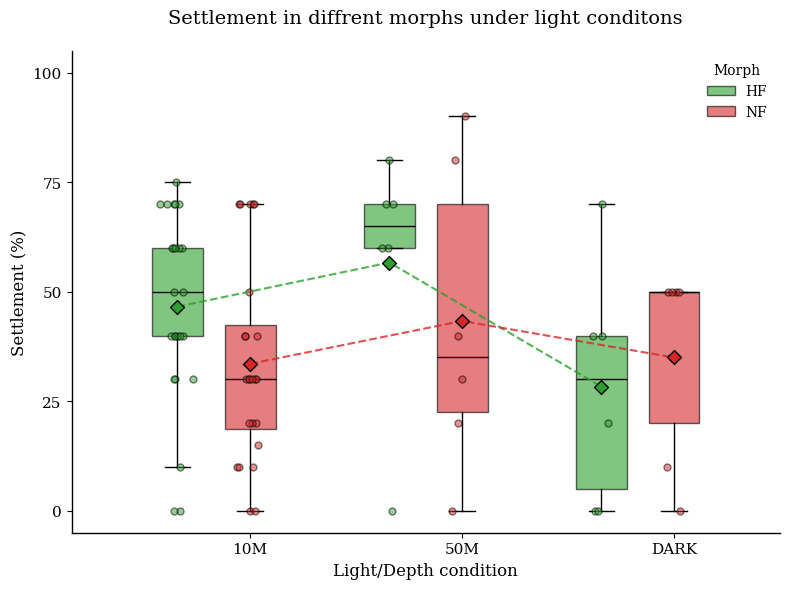


REPORT: Settlement_pH.csv

[DATA DESCRIPTION (N, Mean, 95% CI)]
morph  pH  count      mean       std     ci_95
   HF 7.6      5 42.000000 16.431677 15.665811
   HF 7.8      5 48.000000 19.235384 18.338839
   HF 8.2     25 46.600000 21.637159  7.403726
   NF 7.6      5 20.000000 14.142136 13.482983
   NF 7.8      5 26.000000 19.493589 18.585009
   NF 8.2     24 33.541667 22.769123  7.965608

[STATISTICAL ANALYSIS - ANOVA]
                      sum_sq    df         F    PR(>F)
C(morph)         4224.142616   1.0  9.490777  0.003060
C(pH)             698.851499   2.0  0.785088  0.460490
C(morph):C(pH)    283.858235   2.0  0.318885  0.728125
Residual        28039.958333  63.0       NaN       NaN


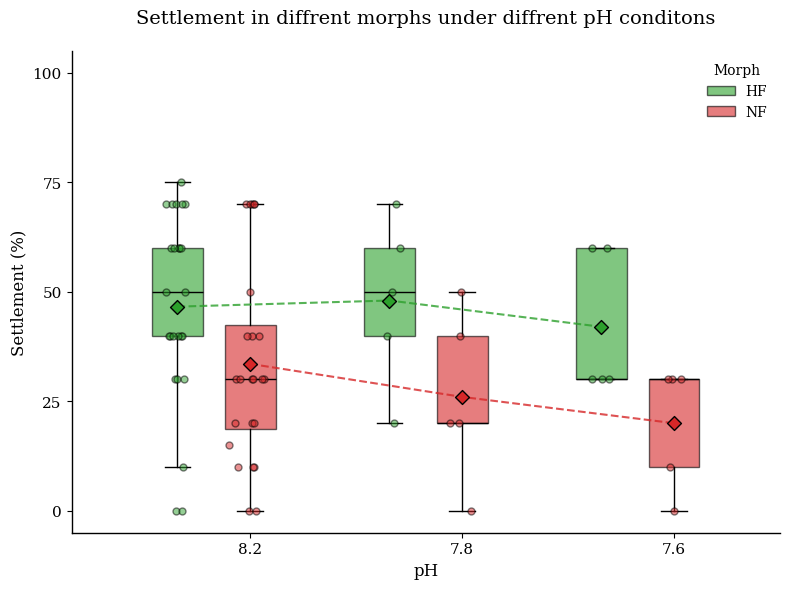


REPORT: Settlement_Temp.csv

[DATA DESCRIPTION (N, Mean, 95% CI)]
morph Temp  count      mean       std     ci_95
   HF   23     25 46.600000 21.637159  7.403726
   HF   27      9 36.666667 26.457513 16.399672
   HF   32     10 22.000000 23.944380 13.880107
   NF   23     24 33.541667 22.769123  7.965608
   NF   27      7 35.714286 30.472470 22.380600
   NF   32      7 18.571429 14.638501 10.751293

[STATISTICAL ANALYSIS - ANOVA]
                        sum_sq    df         F    PR(>F)
C(morph)           1556.676881   1.0  2.901321  0.092593
C(Temp)            5190.287849   2.0  4.836806  0.010537
C(morph):C(Temp)    583.298759   2.0  0.543574  0.582910
Residual          40777.101190  76.0       NaN       NaN


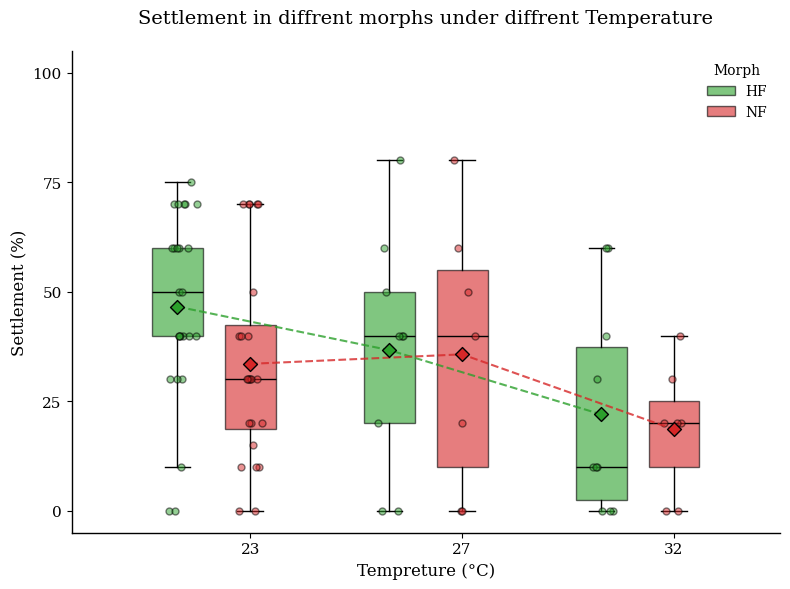

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.ticker as ticker
from statsmodels.formula.api import ols
import statsmodels.api as sm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scipy.stats as stats

# ==========================================
# 1. GLOBAL SETUP & STYLE
# ==========================================
plt.rcParams.update({
    "font.family": "serif",
    "axes.edgecolor": "black", "axes.linewidth": 1,
    "xtick.color": "black", "ytick.color": "black",
    "text.color": "black", "axes.labelcolor": "black",
    "legend.frameon": False,
    "ytick.labelsize": 11,
    "xtick.labelsize": 11
})

# Define colors and fixed order for morphs
variant_colors = {'HF': '#2ca02c', 'PF': '#ff7f0e', 'NF': '#d62728'}
morph_order = ['HF', 'PF', 'NF'] # Original global morph order

# Helper for 95% Confidence Interval
def get_ci(data):
    if len(data) < 2: return 0
    return stats.t.ppf(0.95, len(data)-1) * stats.sem(data)

# ==========================================
# 2. DATA PROCESSING & STATS FUNCTIONS
# ==========================================
def process_settlement_data(df, factor_col, morph_col, target_col):
    df = df.copy()
    # Standardize Morph Names
    df[morph_col] = df[morph_col].astype(str).str.strip().str.lower()
    mapping = {
        'hf': 'HF', 'high fluorescense': 'HF', 'high fluorescense ': 'HF',
        'nf': 'NF', 'no fluorescense': 'NF',
        'pf': 'PF', 'partial fluorescense': 'PF'
    }
    df['morph'] = df[morph_col].map(mapping)
    # The morph_order used here will be the current global morph_order
    df = df[df['morph'].isin(morph_order)].copy()

    # Standardize Factor Values
    if factor_col:
        df[factor_col] = df[factor_col].astype(str).str.strip().str.upper()
        # Correct the replace dictionary to handle '23.0', '27.0', '32.0' as keys
        df[factor_col] = df[factor_col].replace({'23C': '23', '23.0': '23', '27.0': '27', '32.0': '32'})

    # Clean target numerical column
    df[target_col] = pd.to_numeric(df[target_col], errors='coerce')
    df = df.dropna(subset=[target_col, 'morph'])
    return df

def perform_analysis(df, factor_col, target_col):
    """Generates summary table and runs ANOVA + Tukey."""
    # Summary Table
    groups = ['morph'] + ([factor_col] if factor_col else [])
    summary = df.groupby(groups)[target_col].agg(['count', 'mean', 'std']).reset_index()
    summary['ci_95'] = df.groupby(groups)[target_col].apply(get_ci).values

    # ANOVA
    if factor_col and df[factor_col].nunique() > 1:
        formula = f"Q('{target_col}') ~ C(morph) + C({factor_col}) + C(morph):C({factor_col})"
        model = ols(formula, data=df).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        df['group_comb'] = df['morph'].astype(str) + "_" + df[factor_col].astype(str)
        tukey = pairwise_tukeyhsd(endog=df[target_col], groups=df['group_comb'], alpha=0.05)
    else:
        formula = f"Q('{target_col}') ~ C(morph)"
        model = ols(formula, data=df).fit()
        anova = sm.stats.anova_lm(model, typ=2)
        tukey = pairwise_tukeyhsd(endog=df[target_col], groups=df['morph'], alpha=0.05)

    return summary, anova, tukey

# ==========================================
# 3. PLOTTING FUNCTION
# ==========================================
def plot_settlement_with_trends(df, factor_col, target_col, title, x_order, filename, x_axis_label):
    fig, ax = plt.subplots(figsize=(8, 6))

    if factor_col:
        x_pos = np.arange(len(x_order))
        box_width = 1.2 # Increased for wider boxes
        offsets = [-box_width/3.5, 0, box_width/3.5]

        # Uses the current global morph_order
        for i, m in enumerate(morph_order):
            sub = df[df['morph'] == m]
            means = []

            # 1. Boxplots & Points
            data_list = []
            for j, f in enumerate(x_order):
                vals = sub[sub[factor_col] == f][target_col].values
                data_list.append(vals if len(vals) > 0 else [np.nan])

                if len(vals) > 0:
                    means.append((j + offsets[i], vals.mean()))
                    # Raw points
                    x_pts = np.random.normal(j + offsets[i], 0.03, size=len(vals))
                    ax.scatter(x_pts, vals, s=25, color=variant_colors[m], edgecolors='black', alpha=0.5, zorder=3)

            # 2. Draw Boxplots
            bp = ax.boxplot(data_list, positions=x_pos + offsets[i], widths=box_width/5,
                            patch_artist=True, showfliers=False, zorder=2)
            for patch in bp['boxes']:
                patch.set(facecolor=variant_colors[m], alpha=0.6, edgecolor='black')
            plt.setp(bp['medians'], color='black')

            # 3. Connect Means with Dashed Lines
            if len(means) > 1:
                mx, my = zip(*means)
                ax.plot(mx, my, color=variant_colors[m], linestyle='--', linewidth=1.5, alpha=0.8, zorder=4)
                ax.scatter(mx, my, marker='D', s=50, color=variant_colors[m], edgecolors='black', zorder=5)

        ax.set_xticks(x_pos)
        ax.set_xticklabels(x_order)
        ax.set_xlabel(x_axis_label, fontsize=12)
    else:
        # One-factor (Morph only)
        # Uses the current global morph_order
        for i, m in enumerate(morph_order):
            vals = df[df['morph'] == m][target_col]
            if not vals.empty:
                bp = ax.boxplot([vals], positions=[i], widths=0.5, patch_artist=True, showfliers=False)
                bp['boxes'][0].set(facecolor=variant_colors[m], alpha=0.6, edgecolor='black')
                ax.scatter(np.random.normal(i, 0.04, size=len(vals)), vals, s=25, color=variant_colors[m], edgecolors='black', alpha=0.5)
                ax.scatter(i, vals.mean(), marker='D', s=60, color=variant_colors[m], edgecolors='black', zorder=5)
        ax.set_xticks(range(len(morph_order)))
        ax.set_xticklabels(morph_order)

    ax.set_ylabel("Settlement (%)", fontsize=12)
    ax.set_title(title, fontsize=14, pad=20)
    ax.set_ylim(-5, 105)
    ax.yaxis.set_major_locator(ticker.MultipleLocator(25)) # Set y-axis ticks to every 25
    sns.despine()

    # Uses the current global morph_order
    handles = [mpatches.Patch(color=variant_colors[m], label=m, alpha=0.6, ec='black') for m in morph_order]
    ax.legend(handles=handles, title="Morph", loc='upper right')

    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

# ==========================================
# 4. EXECUTION LOOP
# ==========================================
datasets = [
    {"file": "Settlment_Ambient.csv", "factor": None, "morph": "Varient", "order": None, "title": "Settlement in diffrent morphs under ambient conditions", "x_label": None},
    {"file": "Settlement_Depth.csv", "factor": "Light", "morph": "fluorescense level", "order": ["10M", "50M", "DARK"], "title": "Settlement in diffrent morphs under light conditons", "x_label": "Light/Depth condition"},
    {"file": "Settlement_pH.csv", "factor": "pH", "morph": "fluorescense level", "order": ["8.2", "7.8", "7.6"], "title": "Settlement in diffrent morphs under diffrent pH conditons", "x_label": "pH"},
    {"file": "Settlement_Temp.csv", "factor": "Temp", "morph": "fluorescense level", "order": ["23", "27", "32"], "title": "Settlement in diffrent morphs under diffrent Temperature", "x_label": "Tempreture (°C)"}
]

# Store the original morph_order to be able to reset it
original_morph_order = list(morph_order)

for ds in datasets:
    # Determine the morph_order for the current dataset
    if ds['file'] in ["Settlement_Depth.csv", "Settlement_pH.csv", "Settlement_Temp.csv"]:
        # Exclude 'PF' for these specific files
        morph_order = [m for m in original_morph_order if m != 'PF']
    else:
        # Use the full original order for other files (e.g., Ambient)
        morph_order = list(original_morph_order)

    df_raw = pd.read_csv(ds['file'])
    df_clean = process_settlement_data(df_raw, ds['factor'], ds['morph'], 'setteled %')

    # 1. Statistics & Reports
    summary, anova, tukey = perform_analysis(df_clean, ds['factor'], 'setteled %')
    print(f"\n{'='*50}\nREPORT: {ds['file']}\n{'='*50}")
    print("\n[DATA DESCRIPTION (N, Mean, 95% CI)]")
    print(summary.to_string(index=False))
    print("\n[STATISTICAL ANALYSIS - ANOVA]")
    print(anova)

    # 2. Plotting
    plot_settlement_with_trends(df_clean, ds['factor'], 'setteled %', ds['title'], ds['order'], ds['file'].replace(".csv", ".png"), ds.get('x_label', ds['factor']))

# Reset morph_order to its original state after the loop concludes
morph_order = list(original_morph_order)
